In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
import seaborn as sns
import copy
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# df = df.drop([0, 7]) #删除已知的两条脏数据
df = pd.read_excel(r"D:\pycodes\IndustrialProtocolDemo_V19_6_Codex_Baseline_Hotfixed\outputs\final_acceptance_fixture_20260814\encoded_aircraft_door_lock_prediction.xlsx")
y_name = 'historical_price_wan'

D:\anaconda\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df.columns

Index(['scheme_id', 'historical_price_wan', 'attr_001', 'attr_002', 'attr_003',
       'attr_004', 'attr_005', 'attr_006', 'attr_007'],
      dtype='object')

In [3]:
df_describe=df[y_name].describe()
df_std=df_describe.loc['std']
df_std

2.0681385276854574

In [4]:
# 去除离群样本
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.loc[:, df.columns[1]:df.columns[-1]])

# 创建IsolationForest模型
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(scaled_data)
#训练模型并预测异常值
df['is_outlier'] = clf.predict(scaled_data)
# df

In [ ]:
#忽略warning
import warnings
warnings.filterwarnings('ignore')
# 聚类，看看聚类标签与价格标签是否一致
# 找到最佳的k-轮廓系数法
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
silhouette_scores = []

k_values = range(2,10)
n_runs=10
for k in k_values:
    all_cluster_assignments = []
    for i in range(n_runs):
        kmeans = KMeans(n_clusters = k, random_state=42)
        kmeans.fit(scaled_data)
        all_cluster_assignments.append(kmeans)
    
    # 通过比较不同运行的簇内平方和来选择最优结果
    best_cluster_assignment = min(all_cluster_assignments, key = lambda x: x.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, best_cluster_assignment.labels_))
    
# 绘制轮廓系数法图形
# plt.plot(k_values, silhouette_scores, marker = 'o')
# plt.xlabel('簇的数量(k)')
# plt.ylabel('轮廓系数')
# plt.title('簇的轮廓系数')
# plt.show()

In [7]:
# 聚类，看看聚类标签与价格标签是否一致
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.loc[:,df.columns[1]:df.columns[-1]])
# 设置聚类的簇数
num_clusters = 4

# 运行10次KMeans，比较簇内平方和，选择最佳模型
n_runs = 10
best_kmeans = None
lowest_inertia = float('inf')  # 初始化最小簇内平方和
best_cluster_assignments = None

for i in range(n_runs):
    kmeans = KMeans(n_clusters=num_clusters, random_state=i)
    cluster_assignments = kmeans.fit_predict(scaled_data)
    
    if kmeans.inertia_ < lowest_inertia:  # 比较簇内平方和
        lowest_inertia = kmeans.inertia_
        best_kmeans = kmeans  # 保存当前最佳模型
        best_cluster_assignments = cluster_assignments

# # 使用K_means聚类，运行10次
# n_runs=10
# all_cluster_assignments = []
# for i in range(n_runs):
#     kmeans = KMeans(n_clusters = num_clusters, random_state=i)
#     cluster_assignments = kmeans.fit_predict(scaled_data)
#     all_cluster_assignments.append(cluster_assignments)
    
# # 通过比较不同运行的簇内平方和来选择最优结果
# best_cluster_assignment = min(all_cluster_assignments, key = lambda x: kmeans.inertia_)
df['Cluster'] = best_cluster_assignments
# df

D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\a

In [8]:
# 设置价格区间
# df['价格类别'] = pd.cut(df['价格'], bins = [float('-inf'),35000,70000,105000,140000,175000,210000,245000,float('inf')],labels=[0,1,2,3,4,5,6,7])
# df['价格类别'] = pd.cut(df['价格'], bins = [float('-inf'),188103,245606,326251,float('inf')],labels=[0,1,2,3])
# df.to_excel('price_class_cluster_label_data1.xlsx', index=True)
df['价格类别'] = pd.qcut(df['historical_price_wan'], q=num_clusters, labels=range(num_clusters))
price_bins = pd.qcut(df['historical_price_wan'], q=num_clusters, retbins=True)
print(price_bins[1])  # 输出生成的边界区间

# 将结果保存到 Excel
df.to_excel('price_class_cluster_label_data.xlsx', index=False)

print(df[['historical_price_wan', '价格类别']].head())

[12.6   14.475 15.5   17.05  19.6  ]
   historical_price_wan 价格类别
0                  12.6    0
1                  13.8    0
2                  15.2    1
3                  15.0    1
4                  16.9    2


In [9]:
df = df[(df['is_outlier'] != -1) ]

In [10]:
cross_tab = pd.crosstab(df['价格类别'],df['Cluster'])

Text(0.5, 1.0, 'Correlation Heatmap: 价格类别 vs. cluster')

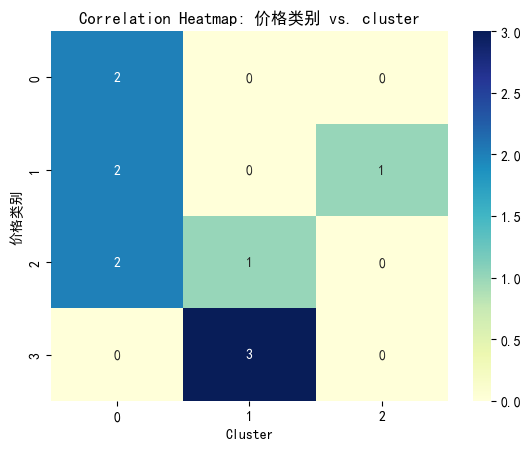

In [11]:
import seaborn as sns
heatmap_data = cross_tab

# 绘制热力图
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation Heatmap: 价格类别 vs. cluster')

In [12]:
from sklearn.model_selection import train_test_split
import random
# 生成一个随机数种子并保存到变量中
# randomnumber = random.randint(1, 10000)
numbers = [2491]
randomnumber = random.choice(numbers)
print("随机数种子：",randomnumber)
# 价格分层抽样
df = df.drop(columns=['is_outlier'])


随机数种子： 2491


In [14]:
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['价格类别'], random_state=randomnumber)
# 删除”价格类别"列
train_df = train_df.drop(columns=['价格类别'])
test_df = test_df.drop(columns=['价格类别'])
# train_df, test_df

In [15]:
df_X = df.loc[:,df.columns[2]:'Cluster']
df_y = df[y_name]
X_train = train_df.loc[:,df.columns[2]:'Cluster']
y_train = train_df[y_name]
y_train = np.log(y_train)
X_test = test_df.loc[:, df.columns[2]:'Cluster']
y_test = test_df[y_name]
# 打印训练数据集和测试数据集的观测数量
print('训练数据集共有%d条观测' % X_train.shape[0])
print('测试数据集共有%d条观测' % X_test.shape[0])
X_train
# y_test

训练数据集共有7条观测
测试数据集共有4条观测


,attr_001,attr_002,attr_003,attr_004,attr_005,attr_006,attr_007,Cluster
8,1,0,1,0,12800,6.0,57,1
9,0,1,0,1,9000,5.0,54,0
4,1,0,1,2,12000,5.8,57,1
11,0,1,1,1,11800,5.7,56,0
6,1,0,2,1,13500,4.9,58,1
5,0,1,0,0,10000,5.0,54,0
3,0,1,0,1,9800,5.1,55,0


In [17]:
# 数据标准化
from sklearn.preprocessing import MinMaxScaler  
scaler = MinMaxScaler(feature_range=(0, 1))  # 指定缩放的范围  
scaler.fit(X_train)  # 用训练集的数据来拟合scaler  
# 用训练集的数据来拟合scaler并进行标准化
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 注意这里使用transform而不是apply

# 保存原始的X_test
X_test_original = X_test.copy()

# 将标准化后的数组转换回DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)




X_test.to_excel('X_test.xlsx')
y_test.to_excel('y_test.xlsx')

X_train

,attr_001,attr_002,attr_003,attr_004,attr_005,attr_006,attr_007,Cluster
8,1.0,0.0,0.5,0.0,0.844444,1.000000,0.75,1.0
9,0.0,1.0,0.0,0.5,0.000000,0.090909,0.00,0.0
4,1.0,0.0,0.5,1.0,0.666667,0.818182,0.75,1.0
11,0.0,1.0,0.5,0.5,0.622222,0.727273,0.50,0.0
6,1.0,0.0,1.0,0.5,1.000000,0.000000,1.00,1.0
5,0.0,1.0,0.0,0.0,0.222222,0.090909,0.00,0.0
3,0.0,1.0,0.0,0.5,0.177778,0.181818,0.25,0.0


In [18]:
# In[15]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# # 创建线性回归模型
# linear_model = LinearRegression()
# # 通过交叉验证选择最佳模型
# predict = cross_val_predict(linear_model, X_train, y_train, cv=10)  # 使用 10 折交叉验证

# # 在训练集上训练模型
# linear_model.fit(X_train, y_train)
# # 在测试集上进行预测
# linear_predictions = linear_model.predict(X_test)
# max_allowed_log_value = np.log(np.finfo(np.float64).max)
# linear_predictions = np.clip(linear_predictions,a_min=None,a_max=max_allowed_log_value)
# linear_predictions = np.exp(linear_predictions)

# 模型分析
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100
# # 计算平均绝对百分比误差
# model1_mape = mean_absolute_percentage_error(y_test, linear_predictions)

# print("LR模型的平均绝对百分比误差：", model1_mape)
# # 计算每个样本的残差
# residuals = np.exp(y_train)-np.exp(predict)
# #计算残差的标准差作为置信度估计
# confidence = np.std(residuals)
# model1_mse = mean_squared_error(y_test,  linear_predictions)
# print("均方误差 (MSE):", model1_mse)
# model1_rmse = np.sqrt(model1_mse)
# print("均方根误差 (RMSE):", model1_rmse)
# model1_mae = mean_absolute_error(y_test,  linear_predictions)
# print("平均绝对误差 (MAE):", model1_mae)
# model1_r2 = r2_score(y_test,  linear_predictions)
# print("R^2 得分:", model1_r2)
# print("预测值的置信度（标准差）：",confidence)

In [19]:
def draw_result(predictions, X_test, y_test):
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    X = range(1, len(X_test) + 1)
    bar_width = 0.4  # 柱状图宽度

    plt.figure(figsize=(16, 9))
    error = np.abs(np.array(y_test) - np.array(predictions)) / 2
    # 将折线图改为分组柱状图
    plt.bar(X, y_test, width=bar_width, label='真实值', color='orange', alpha=0.5)
    plt.bar([x + bar_width for x in X], predictions, width=bar_width, label='预测值', color='b', alpha=0.5,
           yerr = error, capsize=5)
    mapes =  np.abs(y_test - predictions) / y_test
    # 添加误差值标签
    for x, y, mape in zip(X, predictions, mapes):
        plt.text(x + bar_width, y + mape + 0.01, '{:.2%}'.format(mape), ha='left',  fontsize=12 )


    plt.ylabel('价格', fontsize=20)
    plt.xlabel('测试集', fontsize=20)
    plt.tick_params(labelsize=20)
    plt.legend(['真实值', '预测值'], fontsize=30)
    plt.title('在测试集上的预测效果', fontsize=30)
    plt.xticks([x + bar_width / 2 for x in X], X)
    plt.savefig('result.png')
    plt.show()
    #把图片保存到本地

In [20]:
from matplotlib.ticker import FuncFormatter
def draw_mapes_hist(y_test, predictions):
    mapes = np.abs(y_test - predictions) / y_test

    plt.hist(mapes, bins = 5, color = 'blue', alpha =0.7)
    def percent_format(x, pos):
        return f'{x * 100:.2f}%'

    plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))
    plt.xlabel('值')
    plt.ylabel('频数')
    plt.title('mape直方图')
    plt.show()

In [21]:
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score

# 计算置信区间 直接计算法
def calculate_confidence_intervals(predicted_values, std_devs):
    z_value = 1 

    lower_bounds = predicted_values - z_value * std_devs
    upper_bounds = predicted_values + z_value * std_devs

    return lower_bounds, upper_bounds


#新的三条标准
def new_3_indictors(df_X, df_y, X_test, y_test, pred, model, model_name):
 
    # 1. 计算 R² 分数
    r2 = r2_score(y_test, pred)
    print(f'R² score: {r2}')

    
    
    residuals = y_test-pred
#计算残差的标准差作为置信度估计
#     confidence = np.std(residuals)
    confidence = np.std(pred)

    lower_bounds, upper_bounds = calculate_confidence_intervals(pred, confidence)

    ci_width = upper_bounds - lower_bounds

    print(f'Confidence Interval Width: {ci_width}')

    
    
    # 3. 计算模型稳定性（使用平均绝对误差百分比）
    n_splits = min(5, len(X_test))  # 确保 n_splits 小于等于样本数量
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=1) # 交叉验证
    mape_scores = []

    for train_index, test_index in cv.split(df_X):
        X_cv_train, X_cv_test = df_X.iloc[train_index], df_X.iloc[test_index]
        y_cv_train, y_cv_test = df_y.iloc[train_index], df_y.iloc[test_index]
        model.fit(X_cv_train, y_cv_train)  # 重新训练模型
        y_cv_pred = model.predict(X_cv_test)
        mape = mean_absolute_percentage_error(y_cv_test, y_cv_pred)
        mape_scores.append(mape)

    # 计算MAPE的标准差和平均值
    mape_scores = np.array(mape_scores)
    stability = np.std(mape_scores)
    print(f'Model Stability (Std of MAPE): {stability}')

    # 输出评估结果
    if r2 > 0.6:
        print("R² score is acceptable.")
    else:
        print("R² score is too low.")

    specific_width_value = df_std*2  # bootstap置信区间宽度阈值
    if np.mean(ci_width) < specific_width_value:
        print("Confidence interval width is acceptable.")
    else:
        print("Confidence interval width is too wide.")
        
    specific_stability_value = 20  # 稳定性阈值百分比
    if stability < specific_stability_value:
        print("Model stability is acceptable.")
    else:
        print("Model stability is too low.")
        
    return r2, ci_width, stability

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error

def lasso_regression(X_train, y_train, X_test, y_test):
    # 创建候选 alpha 列表
    alphas = [0.00001,0.0001,0.001, 0.01, 0.1, 1, 10]

    best_alpha = None
    best_score = float('inf')  # 修改为初始值为正无穷大

    # 通过交叉验证选择最佳 alpha
    for alpha in alphas:
        lasso_model = Lasso(alpha=alpha, max_iter=10000)  # 增加 max_iter 参数
        lasso_model.fit(X_train, y_train)  # 在训练集上训练模型
        lasso_predictions = lasso_model.predict(X_test)  # 在测试集上进行预测
#         max_allowed_log_value = np.log(np.finfo(np.float64).max)
#         lasso_predictions = np.clip(lasso_predictions,a_min=None,a_max=max_allowed_log_value)
        lasso_predictions = np.exp(lasso_predictions)
        mae = mean_absolute_error(y_test, lasso_predictions)  # 计算均方绝对误差

        if mae < best_score:  # 修改判断条件，选取最小的均方绝对误差
            best_score = mae
            best_alpha = alpha

    print("Lasso模型的最佳正则化参数：", best_alpha)

    # 创建Lasso回归模型
    lasso_model = Lasso(alpha=best_alpha, max_iter=10000)  # 使用最佳的 alpha 和增加的 max_iter

    # 在训练集上训练模型
    lasso_model.fit(X_train, y_train)

    # 在测试集上进行预测
    lasso_predictions = lasso_model.predict(X_test)
#     max_allowed_log_value = np.log(np.finfo(np.float64).max)
#     lasso_predictions = np.clip(lasso_predictions,a_min=None,a_max=max_allowed_log_value)
    lasso_predictions = np.exp(lasso_predictions)

    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - lasso_predictions

    # 计算残差的标准差
    std_dev = np.std(residuals)

    model2_mse = mean_squared_error(y_test,  lasso_predictions)
    print("均方误差 (MSE):", model2_mse)
    model2_rmse = np.sqrt(model2_mse)
    print("均方根误差 (RMSE):", model2_rmse)
    model2_mae = mean_absolute_error(y_test,  lasso_predictions)
    print("平均绝对误差 (MAE):", model2_mae)
    model2_r2 = r2_score(y_test,  lasso_predictions)
    print("R^2 得分:", model2_r2)
    lasso_mape = mean_absolute_percentage_error(y_test, lasso_predictions)
    print("Lasso模型的平均绝对百分比误差：{:.2f}%".format(lasso_mape))
    lower_bounds, upper_bounds = calculate_confidence_intervals(lasso_predictions, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    return lasso_model, lasso_predictions
lasso_model, lasso_predictions = lasso_regression(X_train, y_train, X_test, y_test)

Lasso模型的最佳正则化参数： 0.001
均方误差 (MSE): 0.1215427591971463
均方根误差 (RMSE): 0.3486298311922637
平均绝对误差 (MAE): 0.28485891347331416
R^2 得分: 0.9736349763129835
Lasso模型的平均绝对百分比误差：1.89%
95% 的置信区间列表: [(15.427363750483892, 15.988655700506847), (13.970061745679864, 14.531353695702819), (15.544023819203213, 16.105315769226166), (19.163305611496668, 19.724597561519623)]


In [23]:
lasso_r2, lasso_ci_width, lasso_stability = new_3_indictors(df_X, df_y,X_test, y_test, lasso_predictions, lasso_model, 'Lasso')

R² score: 0.9736349763129835
Confidence Interval Width: [3.82886861 3.82886861 3.82886861 3.82886861]
Model Stability (Std of MAPE): 0.8834487989920805
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


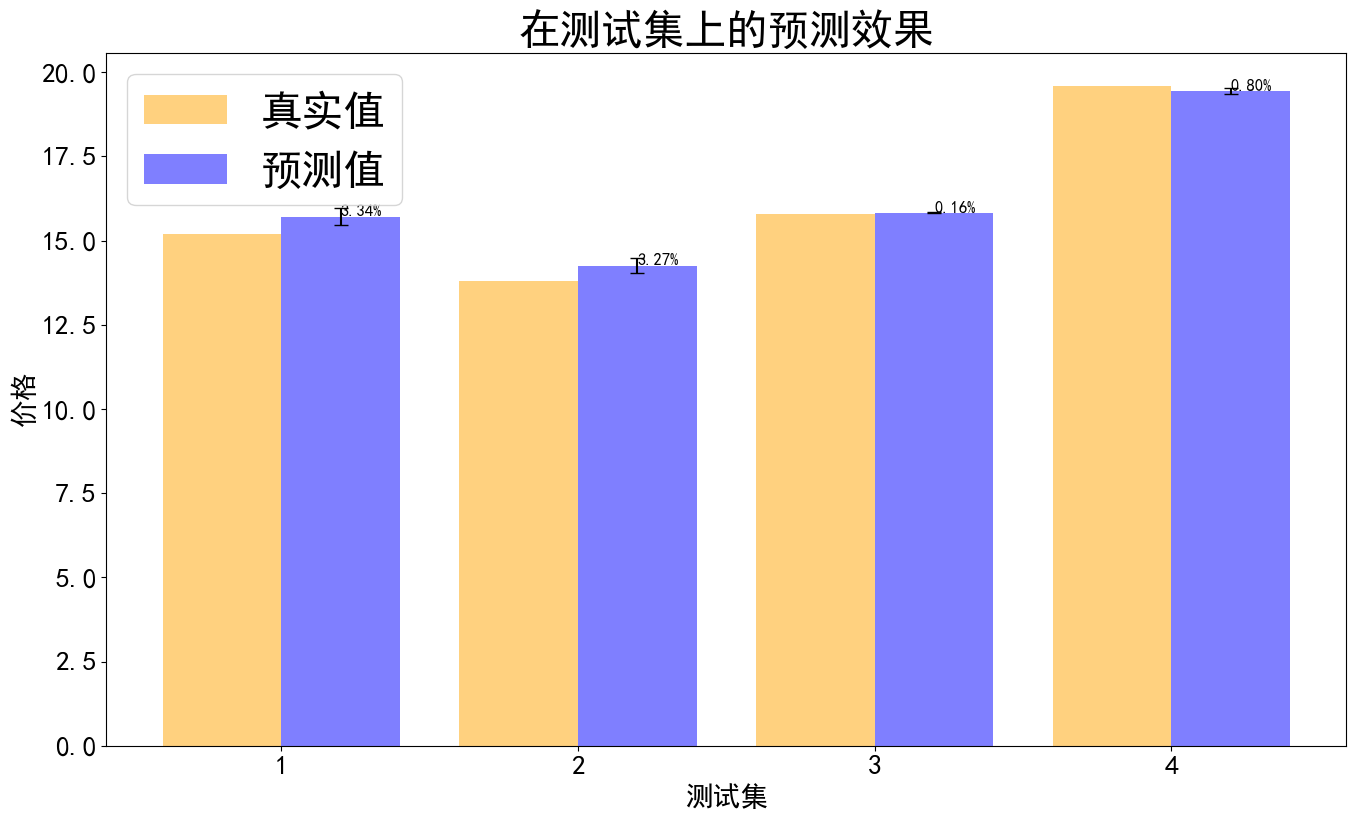

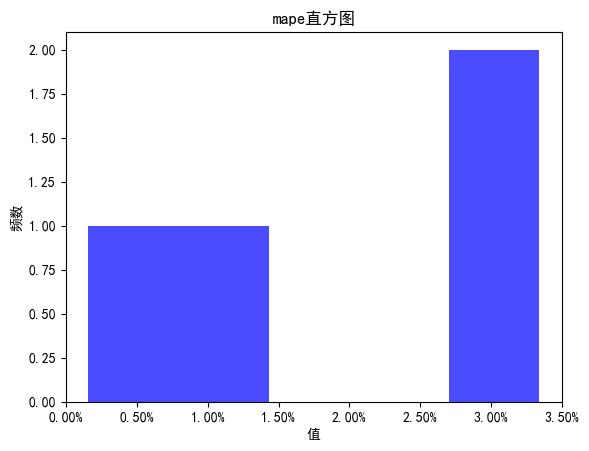

In [24]:
draw_result(lasso_predictions, X_test, y_test)
draw_mapes_hist(y_test, lasso_predictions)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge  # 使用岭回归
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def ridge_regression(X_train, y_train, X_test, y_test):
    # 创建候选 alpha 列表
    alphas = [0.00001,0.0001,0.001, 0.01, 0.1, 1, 10,100]

    best_alpha = None
    best_score = float('inf')  # 修改为初始值为正无穷大

    # 通过交叉验证选择最佳 alpha
    for alpha in alphas:
        ridge_model = Ridge(alpha=alpha)  # 使用岭回归
        ridge_model.fit(X_train, y_train)  # 在训练集上训练模型
        ridge_predictions = ridge_model.predict(X_test)  # 在测试集上进行预测
        #     max_allowed_log_value = np.log(np.finfo(np.float64).max)
#      lasso_predictions = np.clip(lasso_predictions,a_min=None,a_max=max_allowed_log_value)
        ridge_predictions = np.exp(ridge_predictions)
        mse = mean_squared_error(y_test, ridge_predictions)  # 计算均方误差

        if mse < best_score:  # 修改判断条件，选取最小的均方误差
            best_score = mse
            best_alpha = alpha

    print("岭回归模型的最佳正则化参数：", best_alpha)

    # 创建岭回归模型
    ridge_model = Ridge(alpha=best_alpha)  # 使用最佳的 alpha

    # 在训练集上训练模型
    ridge_model.fit(X_train, y_train)

    # 在测试集上进行预测
    ridge_predictions = ridge_model.predict(X_test)
    #     max_allowed_log_value = np.log(np.finfo(np.float64).max)
#     lasso_predictions = np.clip(lasso_predictions,a_min=None,a_max=max_allowed_log_value)
    ridge_predictions = np.exp(ridge_predictions)

    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - ridge_predictions

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model3_mse = mean_squared_error(y_test, ridge_predictions)
    print("均方误差 (MSE):", model3_mse)
    model3_rmse = np.sqrt(model3_mse)
    print("均方根误差 (RMSE):", model3_rmse)
    model3_mae = mean_absolute_error(y_test, ridge_predictions)
    print("平均绝对误差 (MAE):", model3_mae)
    model3_r2 = r2_score(y_test, ridge_predictions)
    print("R^2 得分:", model3_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(ridge_predictions, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    RGlibi=abs(ridge_predictions/y_test-1)
    print("岭回归模型的平均绝对误差百分比:",RGlibi.mean())
    return ridge_model, ridge_predictions
ridge_model,ridge_predictions = ridge_regression(X_train, y_train, X_test, y_test)

岭回归模型的最佳正则化参数： 0.01
均方误差 (MSE): 0.09423720762587984
均方根误差 (RMSE): 0.3069807935781648
平均绝对误差 (MAE): 0.30236310250190623
R^2 得分: 0.9795580894520868
95% 的置信区间列表: [(14.557293117185566, 15.109272465377956), (13.246122447847553, 13.798101796039942), (15.295062814489915, 15.847042162682305), (19.65991013772305, 20.21188948591544)]
岭回归模型的平均绝对误差百分比: 0.018972757308715227


In [26]:
ridge_r2, ridge_ci_width, ridge_stability = new_3_indictors(df_X, df_y,X_test, y_test, ridge_predictions, ridge_model, 'Ridge')

R² score: 0.9795580894520868
Confidence Interval Width: [4.81370165 4.81370165 4.81370165 4.81370165]
Model Stability (Std of MAPE): 1.0663356453946413
R² score is acceptable.
Confidence interval width is too wide.
Model stability is acceptable.


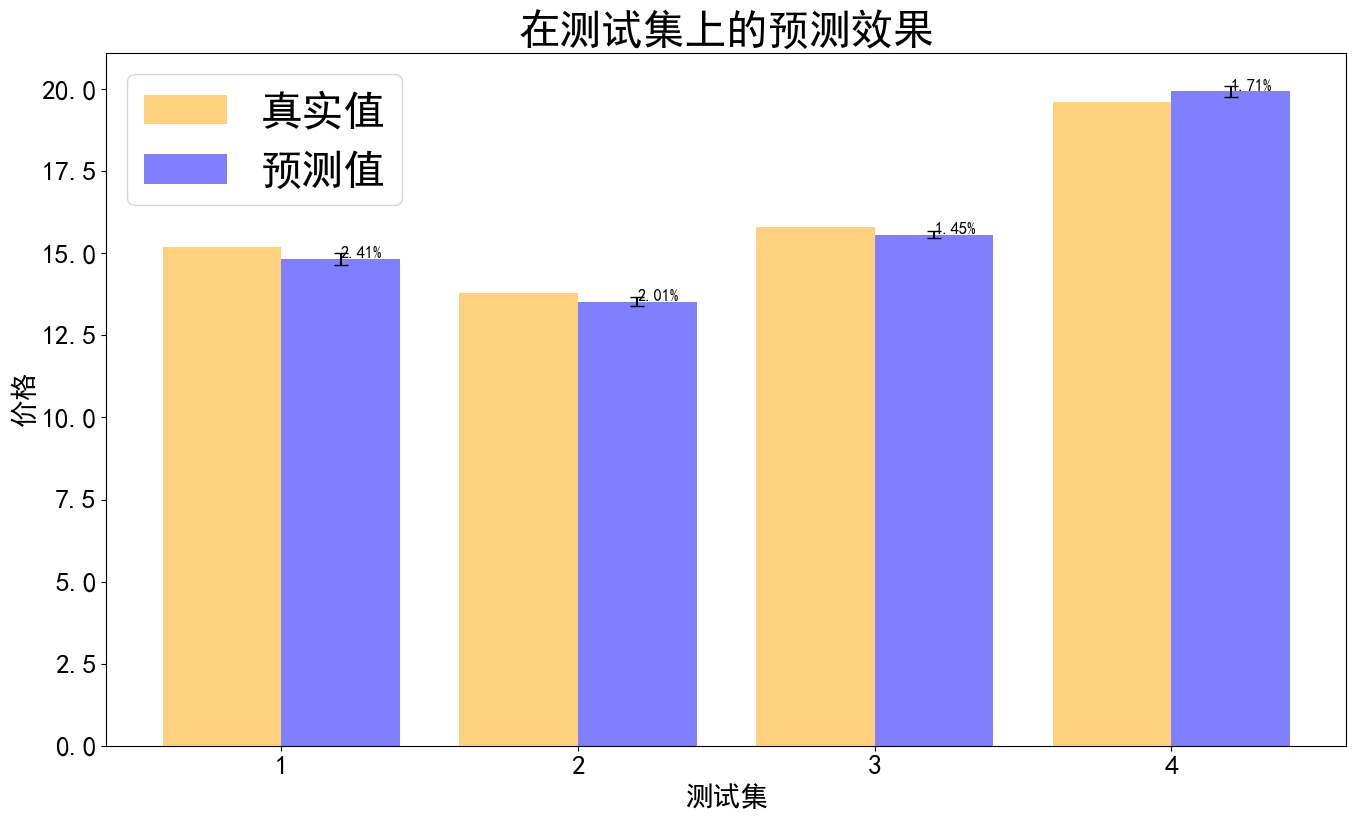

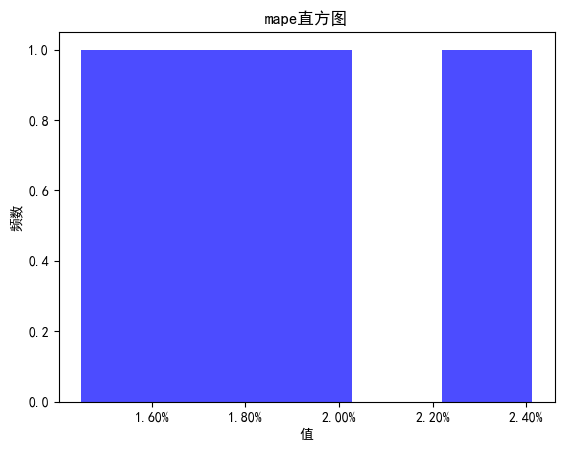

In [27]:
draw_result(ridge_predictions, X_test, y_test)
draw_mapes_hist(y_test, ridge_predictions)

svr最好参数组合： {'C': 100, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'sigmoid'}
均方误差 (MSE): 0.1356868833427911
均方根误差 (RMSE): 0.36835700528534965
平均绝对误差 (MAE): 0.32564258382149047
R^2 得分: 0.9705668365850779
95% 的置信区间列表: [(15.133135661950252, 15.842266055369606), (14.008722939227384, 14.717853332646738), (15.362331503761952, 16.071461897181305), (18.876956762129726, 19.586087155549077)]
平均绝对误差百分比: 0.020951317873936642


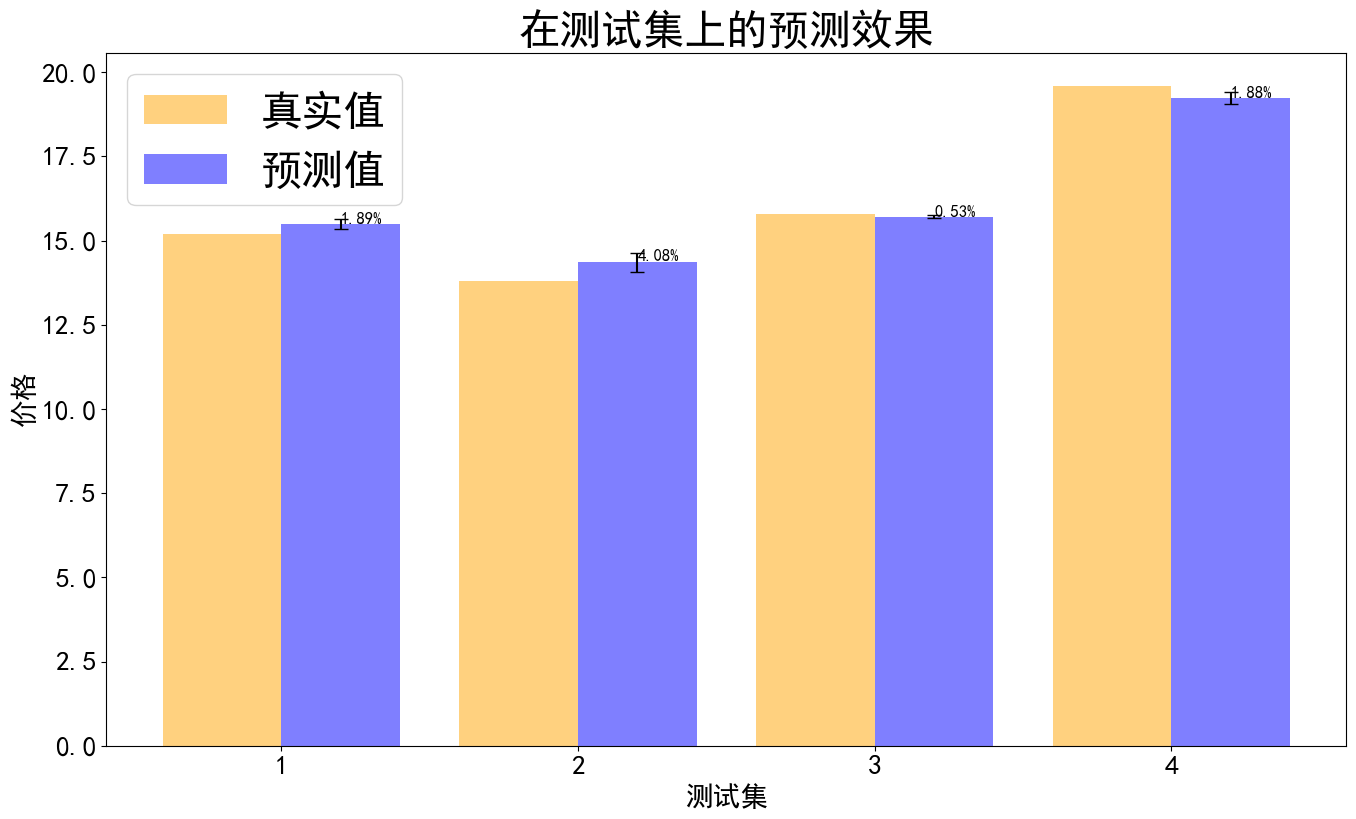

In [28]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
def svr(X_train, y_train, X_test, y_test):
    
        
    # 创建SVR模型
    svr = SVR()
    param_grid = {
        'kernel':['linear','poly','rbf','sigmoid'],#核函数
        'C':[0.001,0.01,0.1,1,10,100,1000,10000,100000],
        'epsilon':[0.01,0.1,0.2],
        'gamma':[0.001,0.01,0.1,1]
    }

    # 使用GridSearchCV进行参数搜索和交叉验证
    grid_svr = GridSearchCV(svr, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error')
    grid_svr.fit(X_train, y_train)
    # 输出测试集上的预测结果
    svr_model = grid_svr.best_estimator_   
    
    print("svr最好参数组合：", grid_svr.best_params_)

    grid_svr_pred = svr_model.predict(X_test)
    grid_svr_pred = np.exp(grid_svr_pred)
    
    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_svr_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model4_mse = mean_squared_error(y_test,grid_svr_pred)
    print("均方误差 (MSE):", model4_mse)
    model4_rmse = np.sqrt(model4_mse)
    print("均方根误差 (RMSE):", model4_rmse)
    model4_mae = mean_absolute_error(y_test, grid_svr_pred)
    print("平均绝对误差 (MAE):", model4_mae)
    model4_r2 = r2_score(y_test, grid_svr_pred)
    print("R^2 得分:", model4_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_svr_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    SVRlibi=abs(grid_svr_pred /y_test-1)
    print("平均绝对误差百分比:",SVRlibi.mean())
    return svr_model, grid_svr_pred
svr_model, grid_svr_pred = svr(X_train, y_train, X_test, y_test)
draw_result(grid_svr_pred, X_test, y_test)

In [29]:
svr_r2, svr_ci_width, svr_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_svr_pred, svr_model, 'SVR')

R² score: 0.9705668365850779
Confidence Interval Width: [3.64751897 3.64751897 3.64751897 3.64751897]
Model Stability (Std of MAPE): 3.449745917298888
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


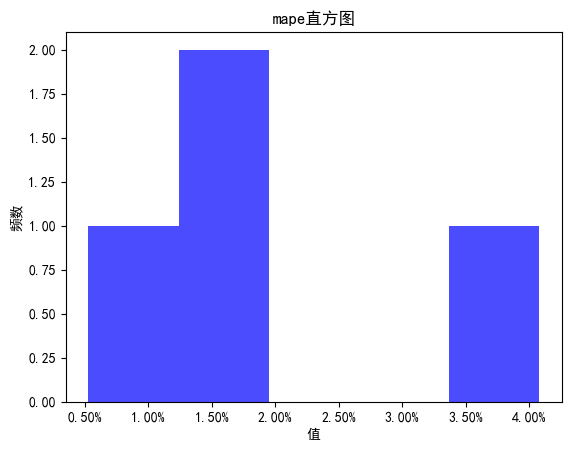

In [30]:
draw_mapes_hist(y_test, grid_svr_pred)

最好参数 {'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.5}
均方误差 (MSE): 2.598574400985431
均方根误差 (RMSE): 1.6120094295584722
平均绝对误差 (MAE): 1.3219280813480498
R^2 得分: 0.43631791735673975
95% 的置信区间列表: [(14.772375601117977, 17.99625566049692), (13.543467035678004, 16.767347095056948), (14.262277443107122, 17.486157502486066), (15.31428781388985, 18.538167873268797)]
平均绝对误差百分比: 0.07931191511882724


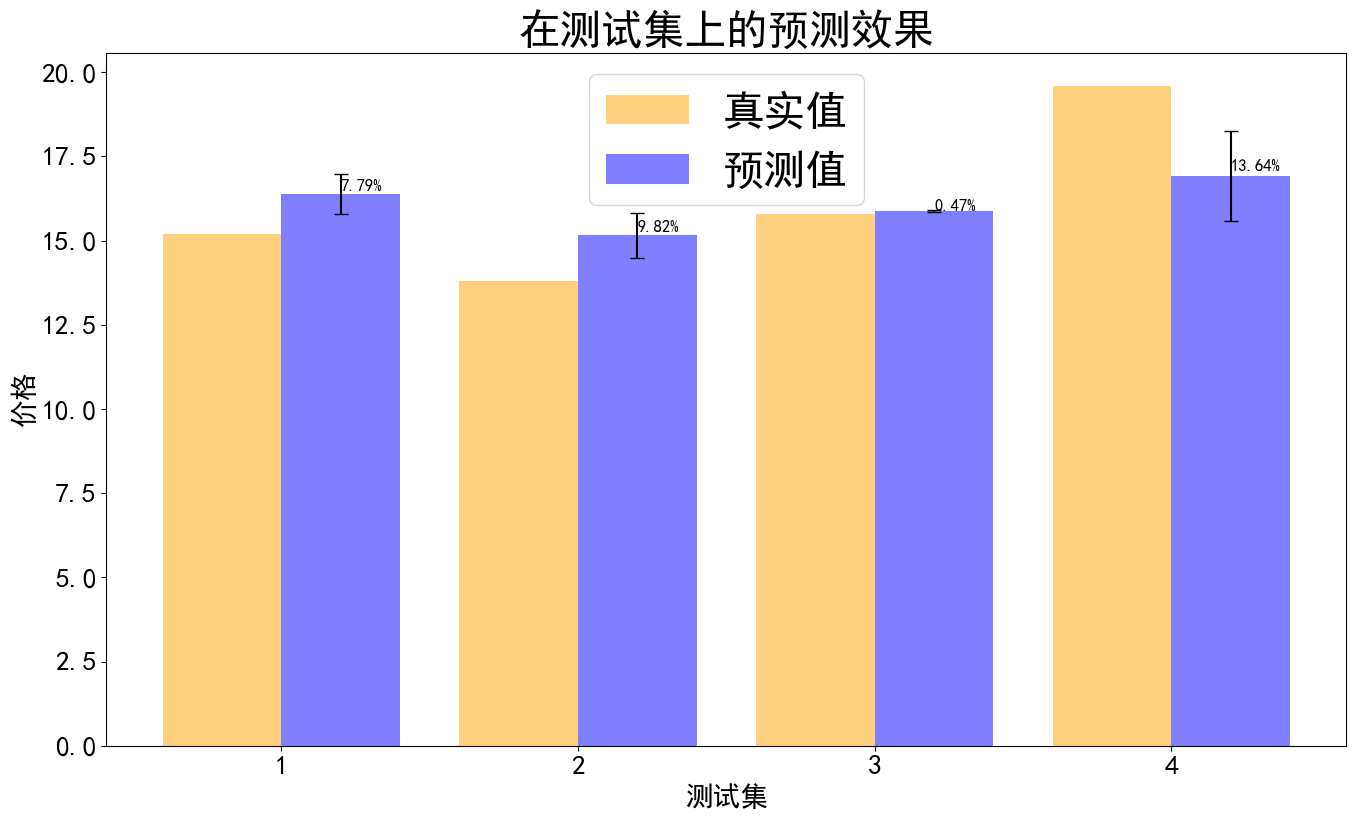

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
def gbdt(X_train, y_train, X_test, y_test):
    # 定义多组参数组合，包括 loss 参数
    param_grid = {
        'min_samples_split': [2],   # 内部节点最小样本数
        'min_samples_leaf': [1,3],     # 叶子节点最小样本数
        'loss': ['huber'],  # 损失函数选项
        'max_depth': [3,],
        'n_estimators': [50,100],
        'learning_rate': [0.01],
        'subsample':[0.5]
    }

    # 创建GradientBoostingRegressor模型
    gbdt = GradientBoostingRegressor()

    # 使用GridSearchCV进行参数搜索和交叉验证
    grid_gbdt = GridSearchCV(estimator=gbdt, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error',n_jobs=-1)
    grid_gbdt.fit(X_train, y_train)
    # 输出测试集上的预测结果
    gbdt_model = grid_gbdt.best_estimator_   
    print("最好参数",grid_gbdt.best_params_)

    grid_gbdt_pred = gbdt_model.predict(X_test)
    grid_gbdt_pred = np.exp(grid_gbdt_pred)

    # 模型分析

    # 计算每个测试样本的残差
    residuals = y_test - grid_gbdt_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)

    model5_mse = mean_squared_error(y_test, grid_gbdt_pred)
    print("均方误差 (MSE):", model5_mse)
    model5_rmse = np.sqrt(model5_mse)
    print("均方根误差 (RMSE):", model5_rmse)
    model5_mae = mean_absolute_error(y_test, grid_gbdt_pred)
    print("平均绝对误差 (MAE):", model5_mae)
    model5_r2 = r2_score(y_test, grid_gbdt_pred)
    print("R^2 得分:", model5_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_gbdt_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    GBDTbili=abs(grid_gbdt_pred/y_test-1)
    print("平均绝对误差百分比:",GBDTbili.mean())
    return gbdt_model, grid_gbdt_pred
gbdt_model, grid_gbdt_pred = gbdt(X_train, y_train, X_test, y_test)
draw_result(grid_gbdt_pred, X_test, y_test)

In [32]:
gbdt_r2, gbdt_ci_width, gbdt_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_gbdt_pred, gbdt_model, 'GBDT')

R² score: 0.43631791735673975
Confidence Interval Width: [1.3060729 1.3060729 1.3060729 1.3060729]
Model Stability (Std of MAPE): 3.0497844811408172
R² score is too low.
Confidence interval width is acceptable.
Model stability is acceptable.


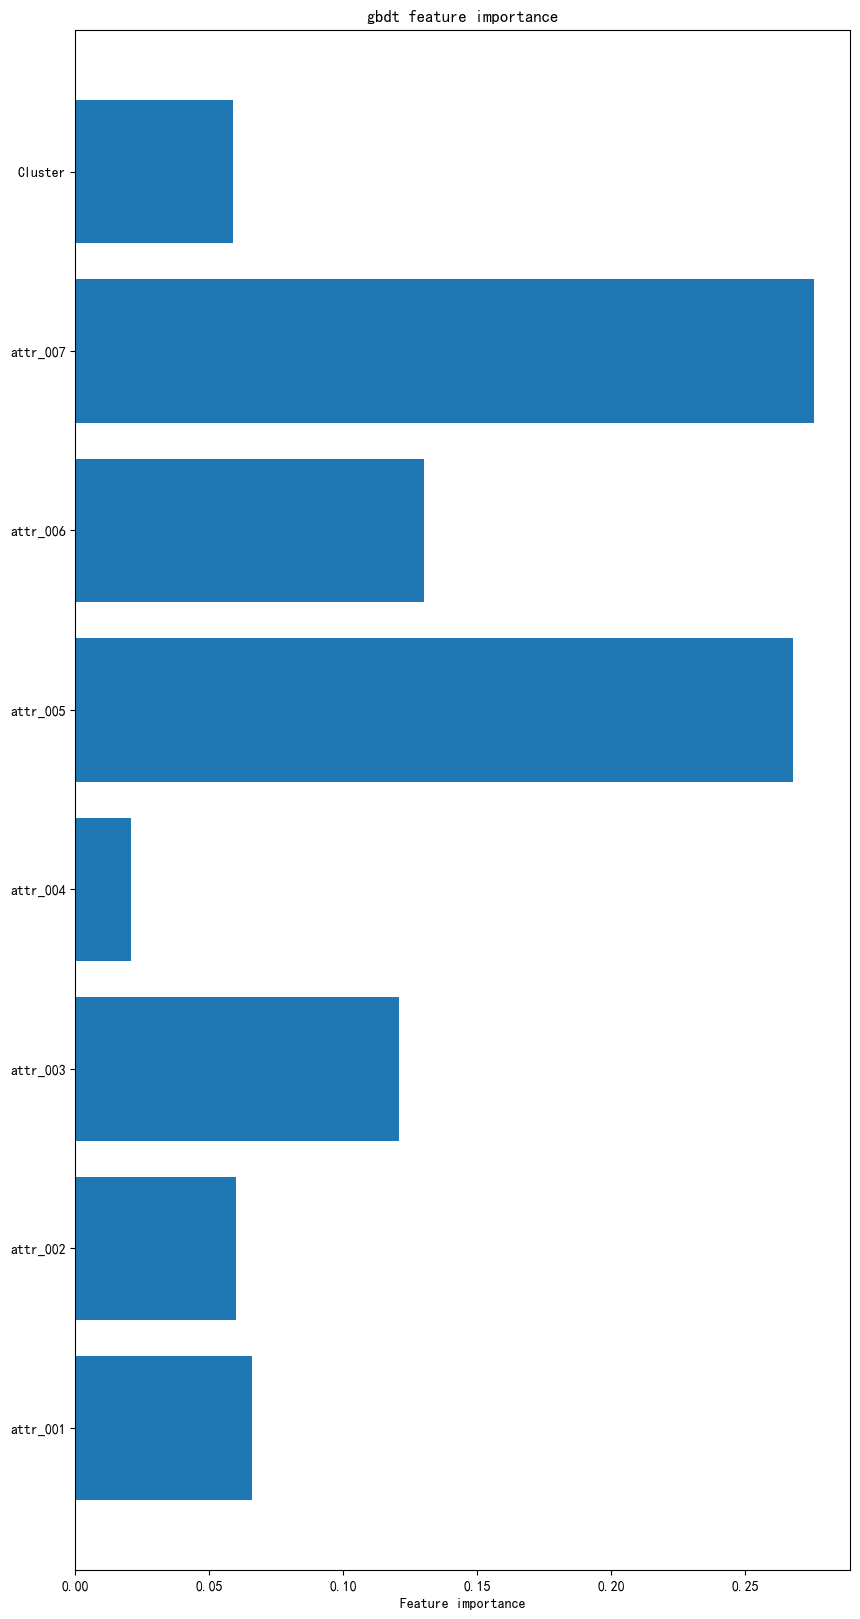

[0.06588407 0.06000745 0.12094245 0.02071226 0.2678663  0.13012462
 0.27559858 0.05886427]


In [33]:
gbdt_importance = gbdt_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(gbdt_importance)),gbdt_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('gbdt feature importance')
plt.show()
print(gbdt_importance)

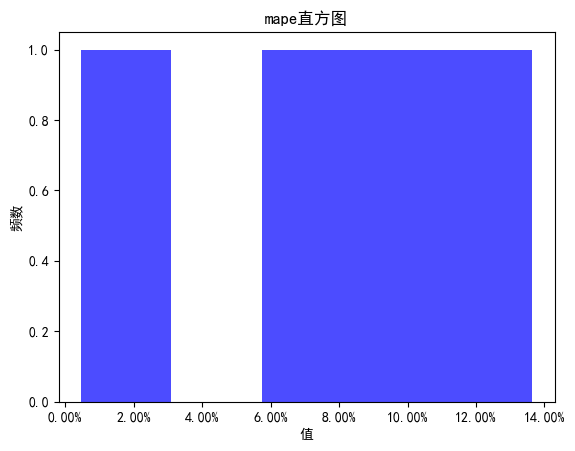

In [34]:
draw_mapes_hist(y_test, grid_gbdt_pred)

In [35]:
X_train

,attr_001,attr_002,attr_003,attr_004,attr_005,attr_006,attr_007,Cluster
8,1.0,0.0,0.5,0.0,0.844444,1.000000,0.75,1.0
9,0.0,1.0,0.0,0.5,0.000000,0.090909,0.00,0.0
4,1.0,0.0,0.5,1.0,0.666667,0.818182,0.75,1.0
11,0.0,1.0,0.5,0.5,0.622222,0.727273,0.50,0.0
6,1.0,0.0,1.0,0.5,1.000000,0.000000,1.00,1.0
5,0.0,1.0,0.0,0.0,0.222222,0.090909,0.00,0.0
3,0.0,1.0,0.0,0.5,0.177778,0.181818,0.25,0.0


最好 {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
均方误差 (MSE): 1.1317675385633328
均方根误差 (RMSE): 1.0638456366237221
平均绝对误差 (MAE): 0.9397647044372386
R^2 得分: 0.7544972801381058
95% 的置信区间列表: [(15.545894911624536, 17.60962202479461), (13.63481426963202, 15.698541382802095), (14.921013834004949, 16.984740947175023), (17.206391310682626, 19.2701184238527)]
平均绝对误差百分比: 0.058149330554648326


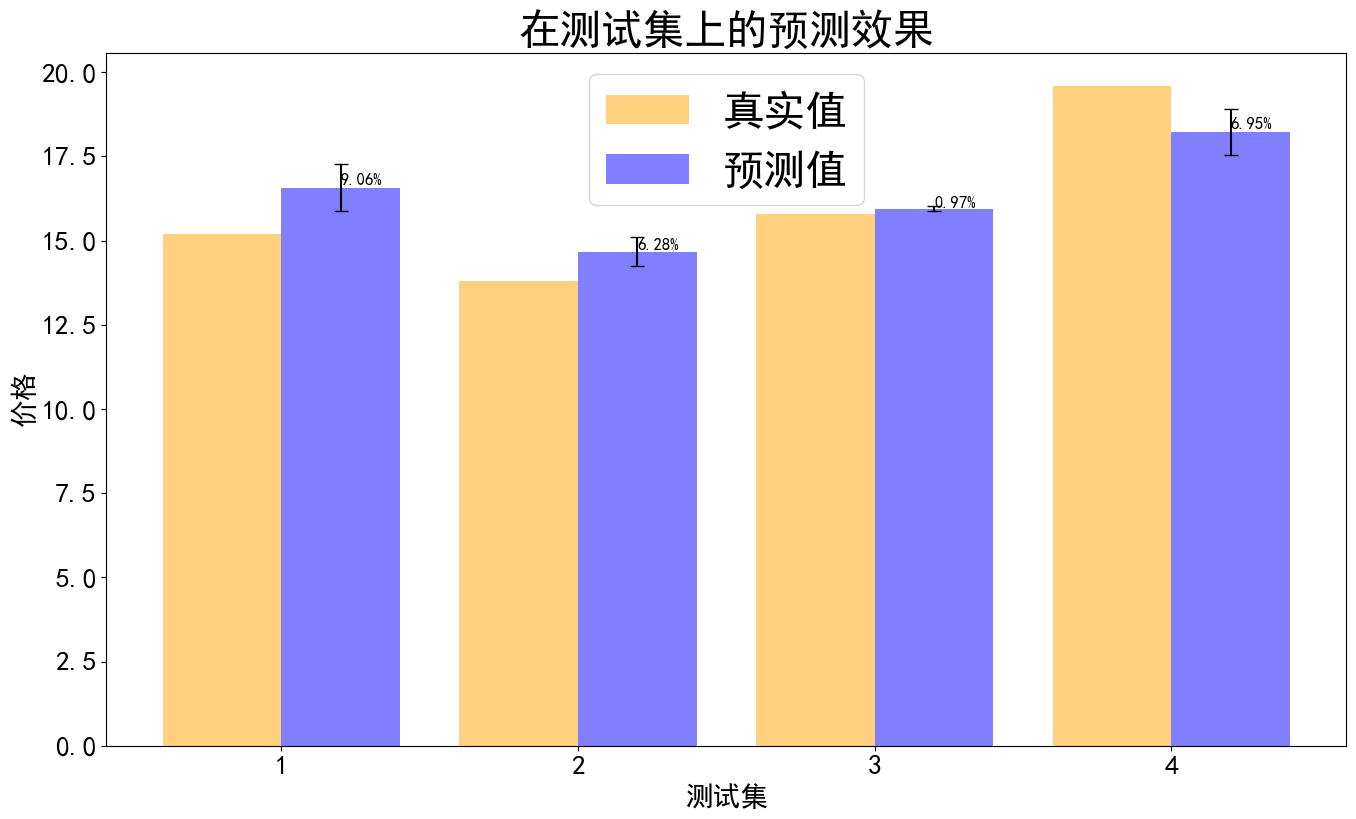

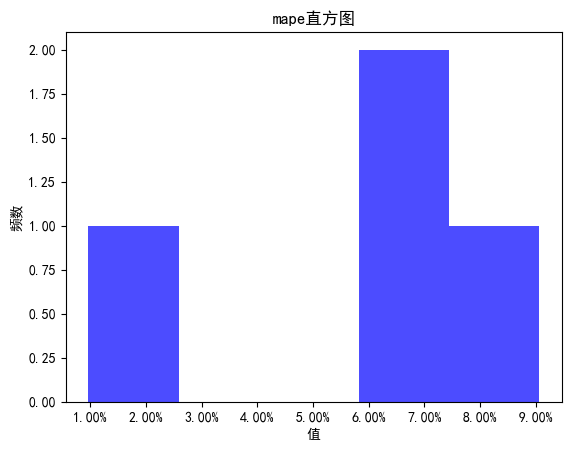

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
import matplotlib.pyplot as plt
def et(X_train, y_train, X_test, y_test):
    # 超参数搜索范围
    max_depth_options = [10]  # 不同的最大深度值
    n_estimators_options = [50]  # 不同的树的数量
    min_samples_split = [2]  # 不同的最小样本拆分值
    min_samples_leaf = [1, 3]

    parameters = {
        'max_depth': max_depth_options,
        'n_estimators': n_estimators_options,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
    }

    # 创建GridSearchCV对象
    grid_et = GridSearchCV(estimator=ExtraTreesRegressor(), param_grid=parameters, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_et.fit(X_train, y_train)
    # 获取最佳参数组合
    best_params = grid_et.best_params_
    # 创建 ExtraTreesRegressor 模型
    et_model = ExtraTreesRegressor(max_depth=best_params['max_depth'], 
                                   n_estimators=best_params['n_estimators'], 
                                   min_samples_split=best_params['min_samples_split'],
                                   min_samples_leaf=best_params['min_samples_leaf']
                                  )

    # 拟合 ExtraTreesRegressor 模型
    et_model.fit(X_train, y_train)
    print("最好",best_params)
    # 使用模型进行预测
    grid_et_pred = et_model.predict(X_test)
    grid_et_pred = np.exp(grid_et_pred)

    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_et_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model6_mse = mean_squared_error(y_test, grid_et_pred)
    print("均方误差 (MSE):", model6_mse)
    model6_rmse = np.sqrt(model6_mse)
    print("均方根误差 (RMSE):", model6_rmse)
    model6_mae = mean_absolute_error(y_test, grid_et_pred)
    print("平均绝对误差 (MAE):", model6_mae)
    model6_r2 = r2_score(y_test, grid_et_pred)
    print("R^2 得分:", model6_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_et_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    ETlibi=abs(grid_et_pred/y_test-1)
    print("平均绝对误差百分比:",ETlibi.mean())
    return et_model, grid_et_pred
et_model, grid_et_pred = et(X_train, y_train, X_test, y_test)
draw_result(grid_et_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_et_pred)

In [37]:
et_r2, et_ci_width, et_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_et_pred, et_model, 'ET')

R² score: 0.7544972801381058
Confidence Interval Width: [2.57066995 2.57066995 2.57066995 2.57066995]
Model Stability (Std of MAPE): 0.8178354005817171
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


In [38]:
df_X

,attr_001,attr_002,attr_003,attr_004,attr_005,attr_006,attr_007,Cluster
1,0,1,1,1,9200,5.4,55,0
2,1,0,2,0,10800,4.2,56,2
3,0,1,0,1,9800,5.1,55,0
4,1,0,1,2,12000,5.8,57,1
5,0,1,0,0,10000,5.0,54,0
6,1,0,2,1,13500,4.9,58,1
7,0,1,1,2,11200,5.6,56,0
8,1,0,1,0,12800,6.0,57,1
9,0,1,0,1,9000,5.0,54,0
10,1,0,2,2,14500,5.2,59,1


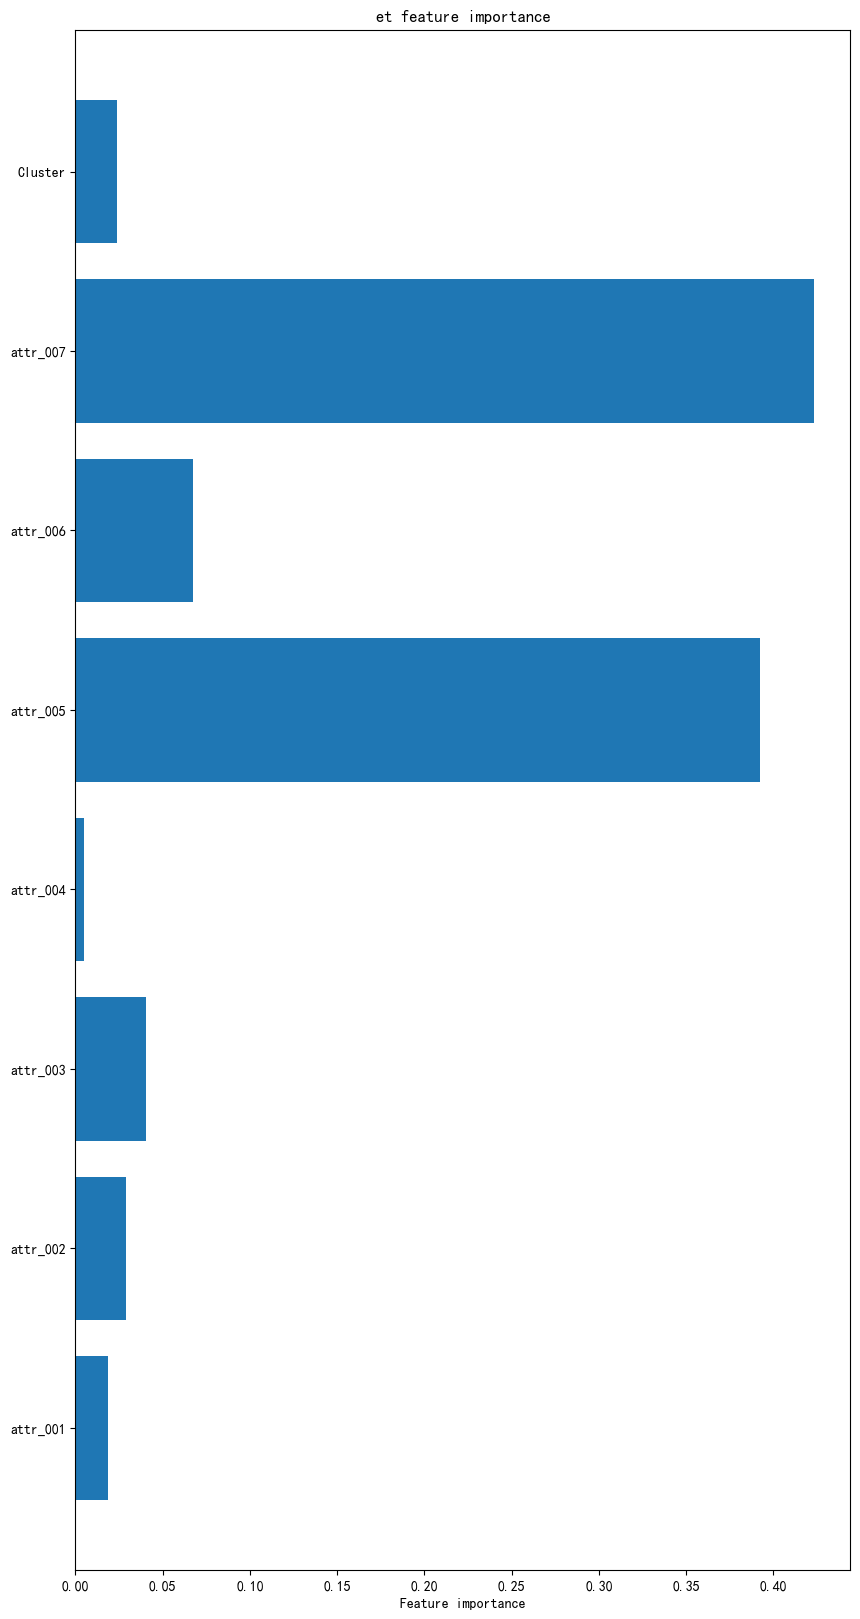

[0.01860207 0.02906694 0.04063843 0.00504614 0.39232544 0.06732865
 0.42304577 0.02394656]


In [39]:
et_importance = et_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(et_importance)),et_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('et feature importance')
plt.show()
print(et_importance)


最好 {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
均方误差 (MSE): 1.7280332024195018
均方根误差 (RMSE): 1.3145467669198772
平均绝对误差 (MAE): 1.1118266705878526
R^2 得分: 0.6251554875445768
95% 的置信区间列表: [(15.209274152946891, 17.829987439607947), (13.543848685439047, 16.164561972100103), (14.549209658126868, 17.169922944787924), (16.27573910082245, 18.896452387483507)]
平均绝对误差百分比: 0.06743243556243753


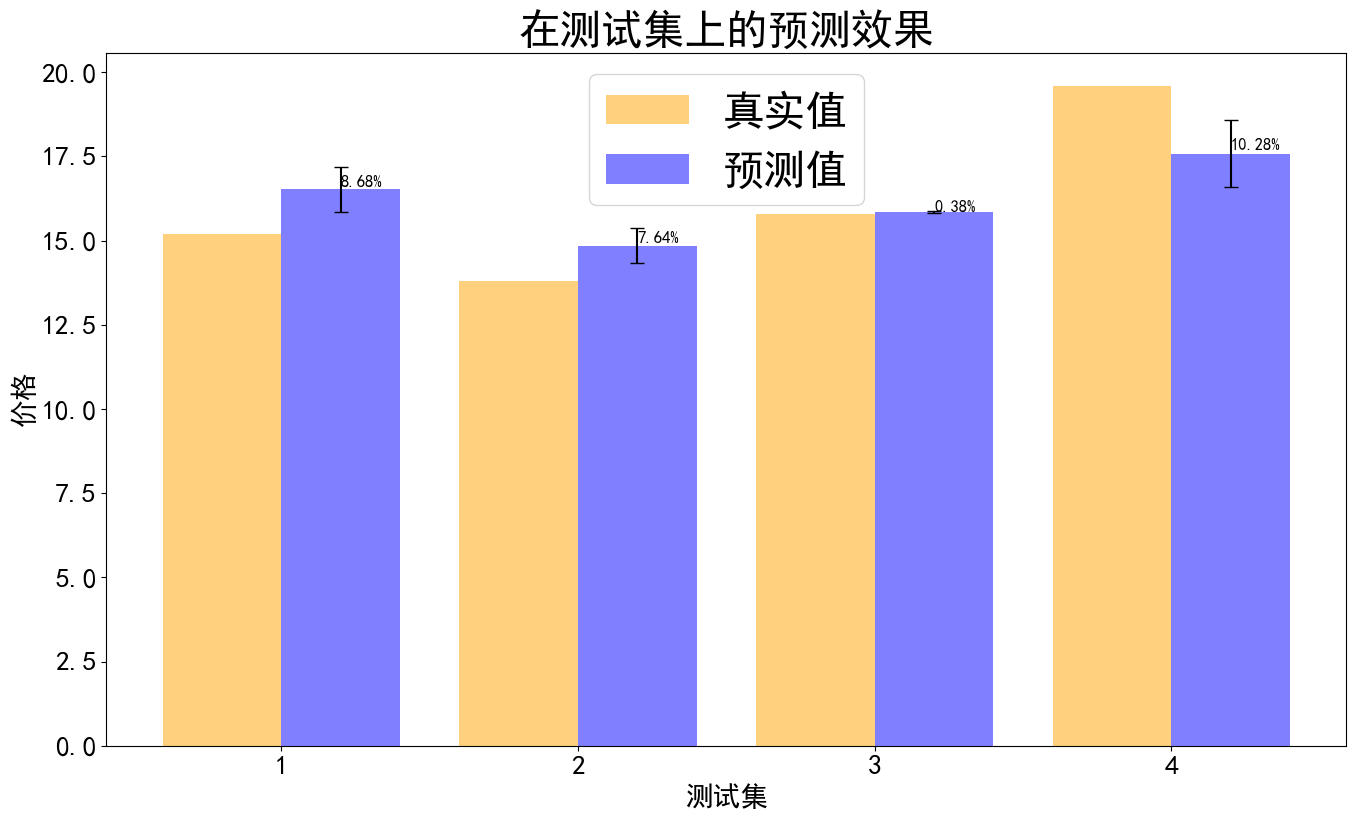

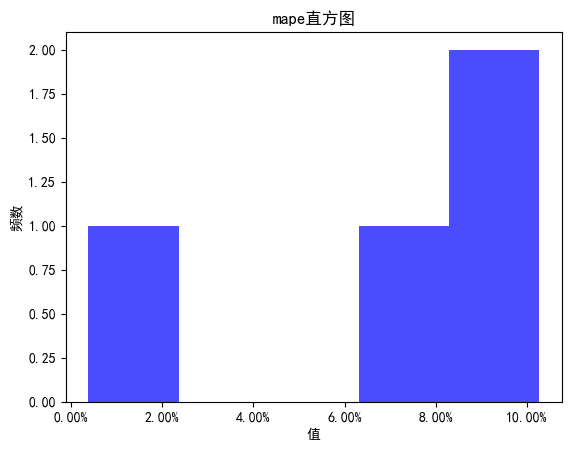

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

def rf(X_train, y_train, X_test, y_test):
    # 超参数搜索范围
    max_depth_options = [10, 20]  # 不同的最大深度值
    n_estimators_options = [50, 100]  # 不同的树的数量
    min_samples_split = [2, 4]  # 不同的最小样本拆分值
    min_samples_leaf = [1, 9]

    parameters = {
        'max_depth': max_depth_options,
        'n_estimators': n_estimators_options,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
    }

    # 创建 GridSearchCV 对象
    grid_rf = GridSearchCV(
        estimator=RandomForestRegressor(),
        param_grid=parameters,
        cv=3,  # 交叉验证折数
        scoring='neg_mean_absolute_error',  # 使用负平均绝对误差作为回归问题的评估指标
        n_jobs=6
    )

    grid_rf.fit(X_train, y_train)

    # 创建 RandomForestRegressor 模型
    rf_model = RandomForestRegressor(max_depth=grid_rf.best_params_['max_depth'],
                                     n_estimators=grid_rf.best_params_['n_estimators'],
                                     min_samples_split=grid_rf.best_params_['min_samples_split'],
                                     min_samples_leaf=grid_rf.best_params_['min_samples_leaf']
                                    )

    # 拟合 RandomForestRegressor 模型
    rf_model.fit(X_train, y_train)
    print("最好",grid_rf.best_params_)
    # 使用模型进行预测
    grid_rf_pred = rf_model.predict(X_test)
    grid_rf_pred = np.exp(grid_rf_pred)
    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_rf_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model7_mse = mean_squared_error(y_test, grid_rf_pred)
    print("均方误差 (MSE):", model7_mse)
    model7_rmse = np.sqrt(model7_mse)
    print("均方根误差 (RMSE):", model7_rmse)
    model7_mae = mean_absolute_error(y_test, grid_rf_pred)
    print("平均绝对误差 (MAE):", model7_mae)
    model7_r2 = r2_score(y_test, grid_rf_pred)
    print("R^2 得分:", model7_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_rf_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    RFlibi=abs(grid_rf_pred/y_test-1)
    print("平均绝对误差百分比:",RFlibi.mean())
    return rf_model, grid_rf_pred
rf_model, grid_rf_pred = rf(X_train, y_train, X_test, y_test)
draw_result(grid_rf_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_rf_pred)

In [41]:
rf_r2, rf_ci_width, rf_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_rf_pred, rf_model, 'RF')

R² score: 0.6251554875445768
Confidence Interval Width: [1.98755846 1.98755846 1.98755846 1.98755846]
Model Stability (Std of MAPE): 1.258676510169237
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


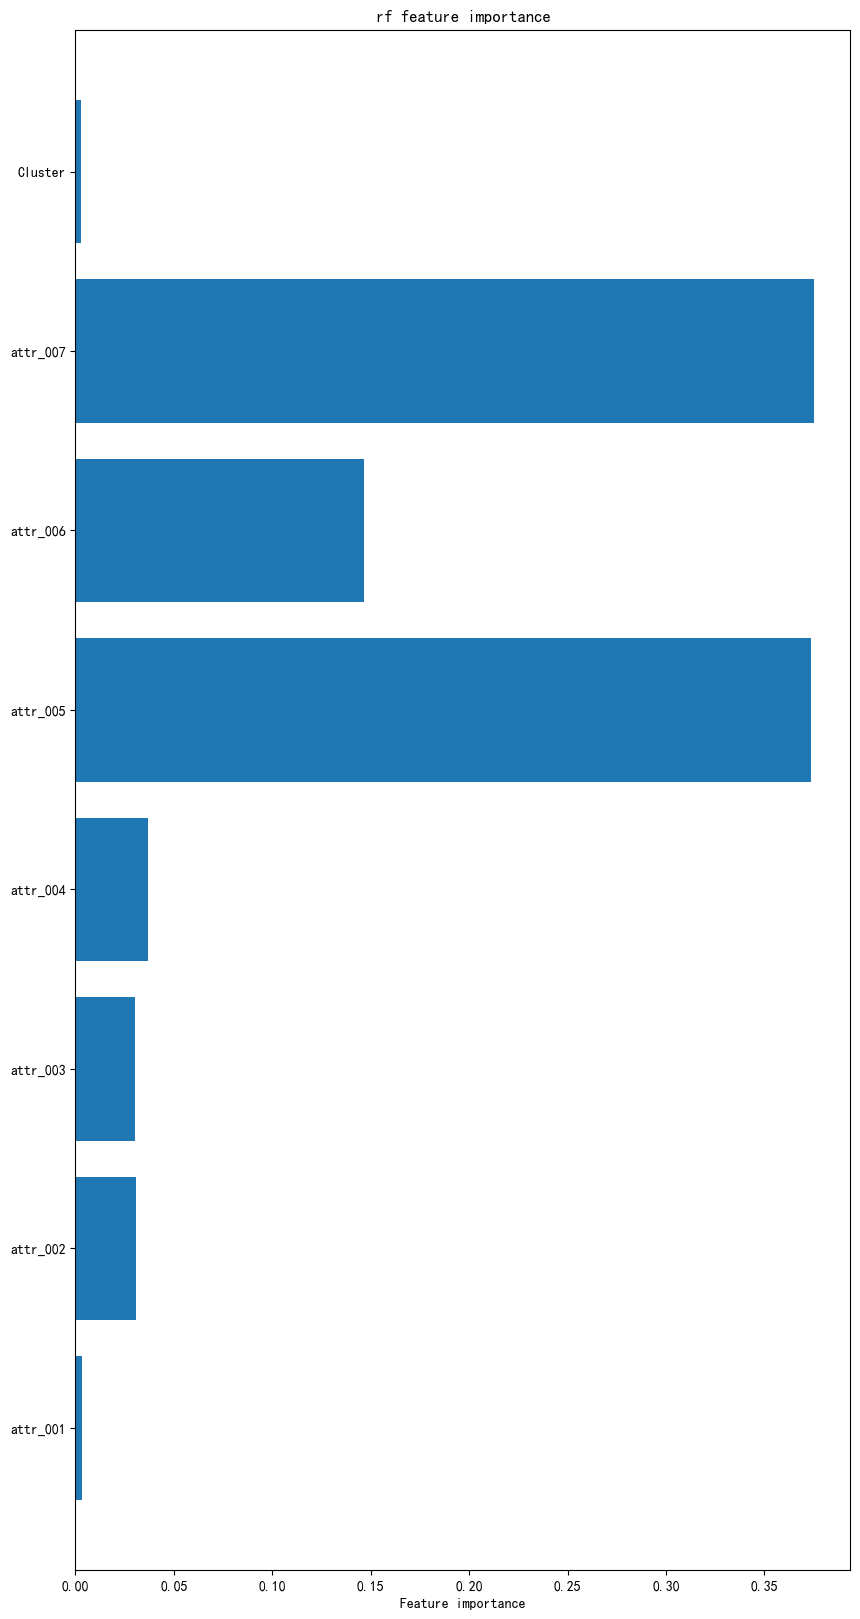

In [42]:
rf_importance = rf_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(rf_importance)),rf_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('rf feature importance')
plt.show()
# print(rf_importance)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

def xgboost(X_train, y_train, X_test, y_test):
    parameters = {
        'max_depth': [3,5,7,9],
        'n_estimators': [50,100,300,500],
        'learning_rate': [0.01,0.1,0.3],
        'min_child_weight': [1, 3, 5,7,9],
        'subsample':[0.5,0.7,0.9,1],
        'colsample_bytree':[0.5,0.7,0.9,1]
    }

    # 创建 GridSearchCV 对象
    grid_xgb = GridSearchCV(
        estimator=xgb.XGBRegressor(),
        param_grid=parameters,
        cv=10,  # 交叉验证折数
        scoring='neg_mean_absolute_error',  # 使用负平均绝对误差作为回归问题的评估指标
        n_jobs=6
    )

    grid_xgb.fit(X_train, y_train)

    # 创建 XGBoostRegressor 模型
    xgb_model = xgb.XGBRegressor(max_depth=grid_xgb.best_params_['max_depth'],
                                 n_estimators=grid_xgb.best_params_['n_estimators'],
                                 min_child_weight=grid_xgb.best_params_['min_child_weight'],
                                 learning_rate=grid_xgb.best_params_['learning_rate'],
                                 subsample=grid_xgb.best_params_['subsample'],
                                 colsample_bytree=grid_xgb.best_params_['colsample_bytree'],
                                 )

    # 训练模型
    xgb_model.fit(X_train, y_train)
    print("最好",grid_xgb.best_params_)
    # 在测试集上进行预测
    grid_xgb_pred = xgb_model.predict(X_test)
    grid_xgb_pred = np.exp(grid_xgb_pred)
    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_xgb_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)

    model8_mse = mean_squared_error(y_test, grid_xgb_pred)
    print("均方误差 (MSE):", model8_mse)
    model8_rmse = np.sqrt(model8_mse)
    print("均方根误差 (RMSE):", model8_rmse)
    model8_mae = mean_absolute_error(y_test, grid_xgb_pred)
    print("平均绝对误差 (MAE):", model8_mae)
    model8_r2 = r2_score(y_test, grid_xgb_pred)
    print("R^2 得分:", model8_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_xgb_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    XGlibi=abs(grid_xgb_pred/y_test-1)
    print("平均绝对误差百分比:",XGlibi.mean())
    return xgb_model, grid_xgb_pred
xgb_model, grid_xgb_pred = xgboost(X_train, y_train, X_test, y_test)
draw_result(grid_xgb_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_xgb_pred)

In [ ]:
xgb_r2, xgb_ci_width, xgb_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_xgb_pred, xgb_model, 'XGBoost')

In [ ]:
xgb_importance = xgb_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(xgb_importance)),xgb_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('xgb feature importance')
plt.show()
print(xgb_importance)

weight： [7.04107388 7.03391578 2.18794796 3.11625846 6.83605972 1.        ]
weight： [0.2587179  0.25845488 0.08039417 0.1145041  0.25118484 0.0367441 ]
原y_pred：
[[15.70800973 14.83328279 16.5196308  16.57775847 15.48770086 16.38431563]
 [14.25070772 13.52211212 14.85420533 14.66667783 14.36328814 15.15540707]
 [15.82466979 15.57105249 15.8595663  15.95287739 15.7168967  15.87421747]
 [19.44395159 19.93589981 17.58609574 18.23825487 19.23152196 16.92622784]]
去除离群值后的y_pred:
[[15.70800973         nan 16.5196308  16.57775847 15.48770086 16.38431563]
 [14.25070772         nan 14.85420533 14.66667783 14.36328814 15.15540707]
 [15.82466979         nan 15.8595663  15.95287739 15.7168967  15.87421747]
 [19.44395159 19.93589981 17.58609574 18.23825487 19.23152196         nan]]
每列数据的平均值: [16.135483095889946, 14.658057215396502, 15.845645531906058, 18.88714479371749]
权重每列数据的平均值: [15.61628368 14.22006746 15.75135655 19.13780942]
权重平均绝对误差百分比: 0.021121651692936755


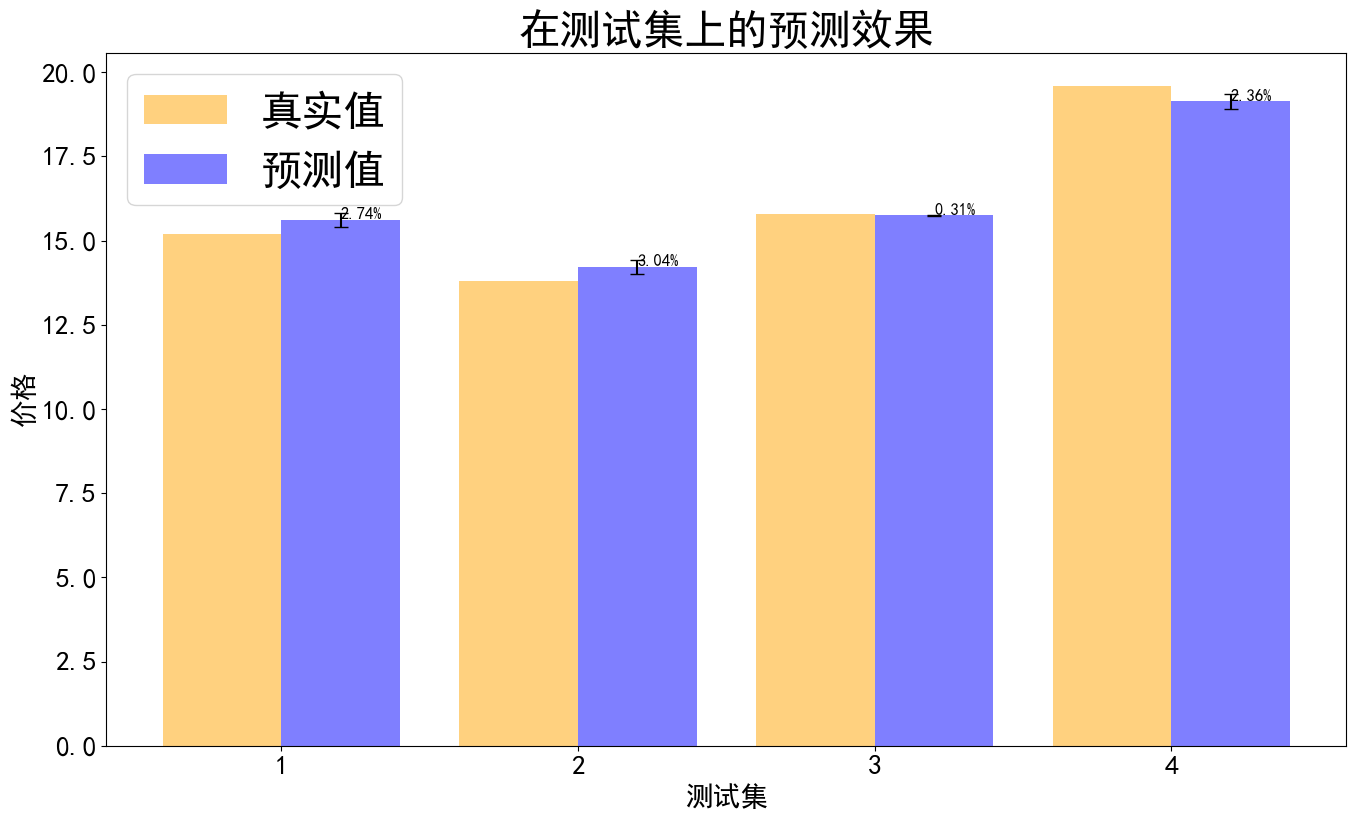

没去除坏值的每列数据的平均值: [15.918449711788583, 14.468733033154379, 15.79988002468607, 18.560325302027795]
没去除坏值的平均绝对误差百分比: 0.037194391168743506


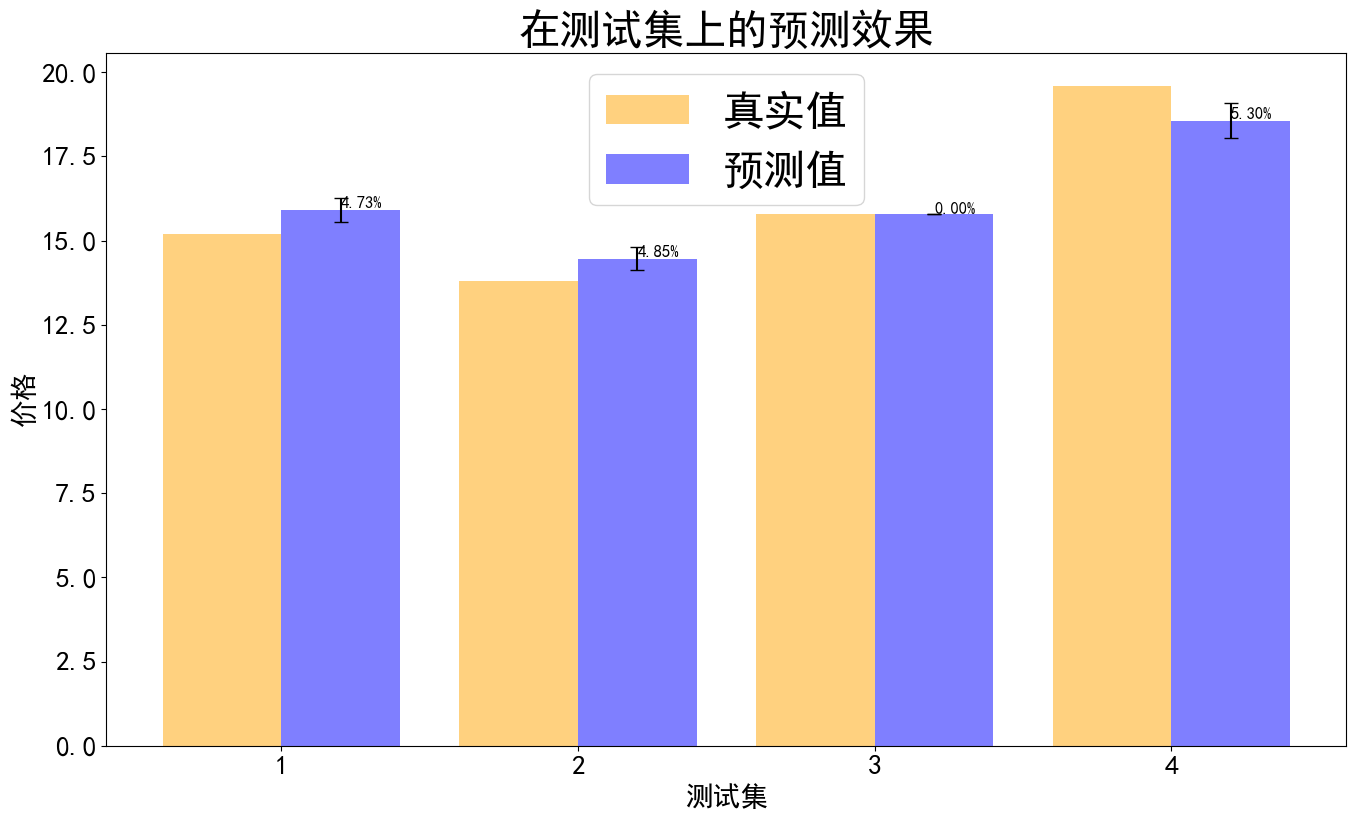

平均绝对误差百分比: 0.040745530226798526


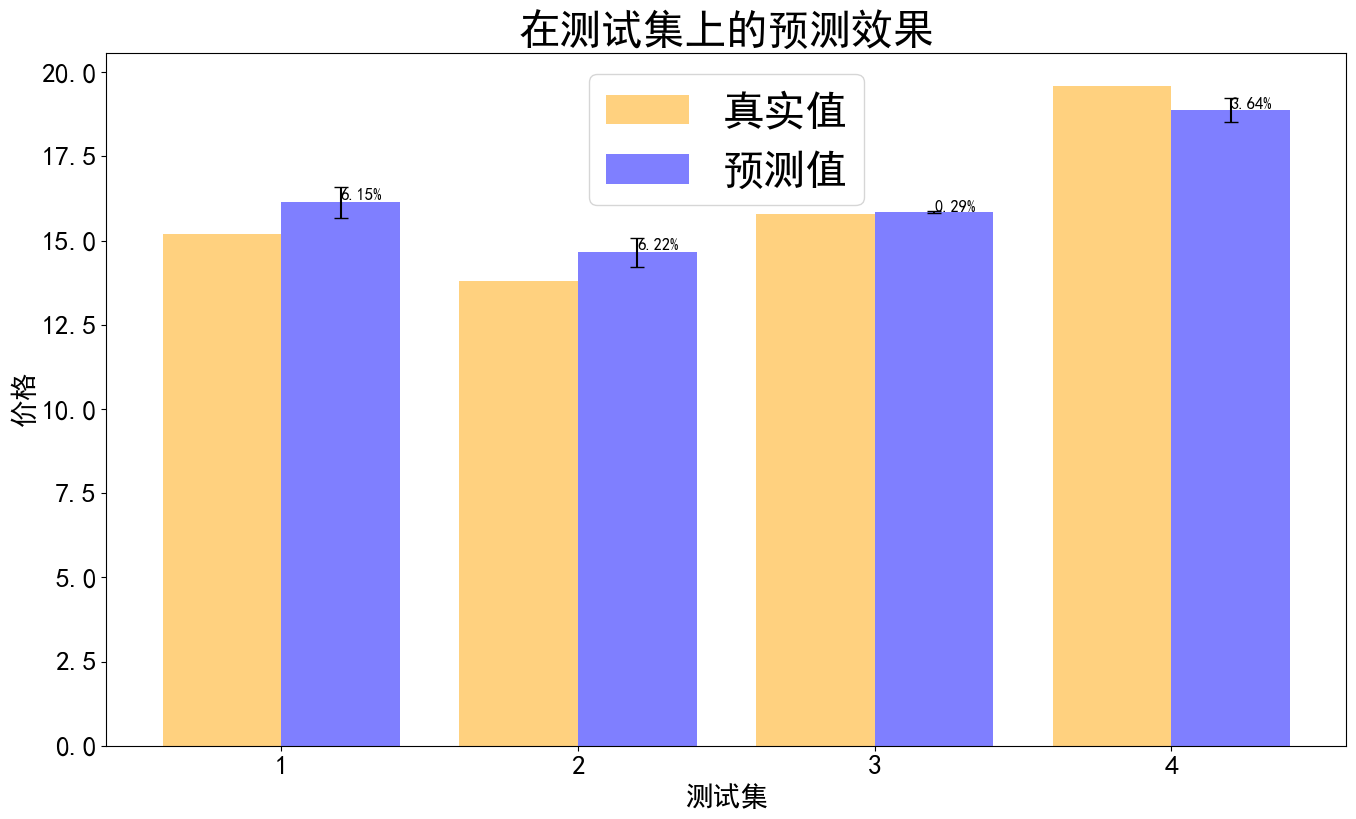

In [43]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 创建一个包含所有数据的数组，其中每一行是一种模型的预测结果
data = np.array([
    lasso_predictions,
    ridge_predictions,
#     grid_xgb_pred,
    grid_rf_pred,
    grid_et_pred,
    grid_svr_pred,
    grid_gbdt_pred
])

lasso_mape_weight = mean_absolute_percentage_error(y_test, lasso_predictions)
ridge_mape_weight = mean_absolute_percentage_error(y_test, ridge_predictions)
# xgb_mape_weight = mean_absolute_percentage_error(y_test, grid_xgb_pred)
rf_mape_weight = mean_absolute_percentage_error(y_test, grid_rf_pred)
et_mape_weight = mean_absolute_percentage_error(y_test, grid_et_pred)
svr_mape_weight = mean_absolute_percentage_error(y_test, grid_svr_pred)
gbdt_mape_weight = mean_absolute_percentage_error(y_test, grid_gbdt_pred)

weight_score = 99-max(lasso_mape_weight,
                   ridge_mape_weight,
#                    xgb_mape_weight,
                   rf_mape_weight,
                   et_mape_weight,
                   svr_mape_weight,
                   gbdt_mape_weight)

lasso_weight = 100 - mean_absolute_percentage_error(y_test, lasso_predictions)-weight_score
ridge_weight = 100 - mean_absolute_percentage_error(y_test, ridge_predictions)-weight_score
# xgb_weight = 100 - mean_absolute_percentage_error(y_test, grid_xgb_pred)-weight_score
rf_weight = 100 - mean_absolute_percentage_error(y_test, grid_rf_pred)-weight_score
et_weight = 100 - mean_absolute_percentage_error(y_test, grid_et_pred)-weight_score
svr_weight = 100 - mean_absolute_percentage_error(y_test, grid_svr_pred)-weight_score
gbdt_weight = 100 - mean_absolute_percentage_error(y_test, grid_gbdt_pred)-weight_score
weights = np.array([lasso_weight,
                    ridge_weight,
#                     xgb_weight,
                    rf_weight,
                    et_weight,
                    svr_weight,
                    gbdt_weight])
print("weight：", weights)
weights /= np.sum(weights)

print("weight：", weights)

print("原y_pred：")
print(data.T)
# 初始化孤立森林模型
clf = IsolationForest(n_estimators=300, 
                      max_samples='auto', 
                      contamination=float(0.1),
                      max_features=1.0)  # contamination参数表示预期的离群值比例

# 存储每列的平均值
column_means = []
cleaned_data = []
ocolumn_means = []

# 对每列数据进行拟合和预测
for column in data.T:  # 转置以便迭代列
    # 拟合孤立森林模型
    clf.fit(column.reshape(-1, 1))  # 转换为列向量
    
    # 预测离群值
    predictions = clf.predict(column.reshape(-1, 1))
    
    # 去除离群值并计算平均值
#     clean_column = column[predictions == 1]  # 去除离群值
#     cleaned_data.append(clean_column)
    clean_column = column.copy()
    clean_column[predictions == -1] = np.nan  # 替换离群值为NaN
    cleaned_data.append(clean_column)
    column_mean = np.nanmean(clean_column)   # 计算平均值
    column_means.append(column_mean)

# column_means 现在包含了每列数据的平均值
cleaned_data = np.array(cleaned_data)
print("去除离群值后的y_pred:")
print(cleaned_data)
print("每列数据的平均值:", column_means)

weight_column_means = np.dot(data.T, weights)
print("权重每列数据的平均值:", weight_column_means)

weight_mean_absolute_error_percentage = np.mean(np.abs((y_test - weight_column_means) / y_test) )
print("权重平均绝对误差百分比:", weight_mean_absolute_error_percentage)
draw_result(weight_column_means, X_test, y_test)

for column in data.T:  # 转置以便迭代列
    o_column = column.copy()
    ocolumn_mean = np.mean(o_column)
    ocolumn_means.append(ocolumn_mean)

print("没去除坏值的每列数据的平均值:", ocolumn_means)

# 计算没去除坏值的平均绝对误差百分比
no_drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - ocolumn_means) / y_test) )
print("没去除坏值的平均绝对误差百分比:", no_drop_mean_absolute_error_percentage)
draw_result(ocolumn_means, X_test, y_test)

# 计算去除坏值的平均绝对误差百分比
drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - column_means) / y_test) )
print("平均绝对误差百分比:", drop_mean_absolute_error_percentage)
draw_result(column_means, X_test, y_test)

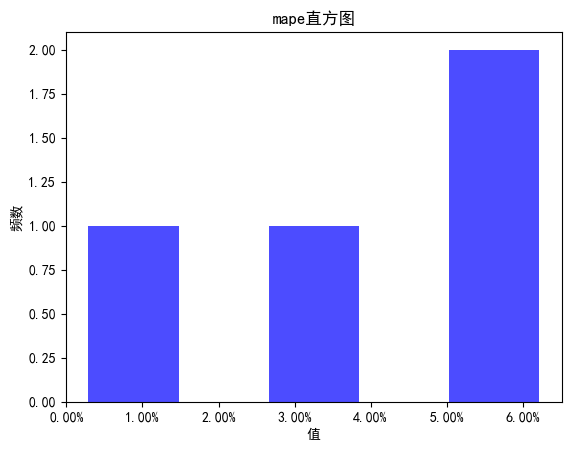

In [44]:
draw_mapes_hist(y_test, column_means)

In [45]:
total_r2 = np.array([
    lasso_r2,
    ridge_r2,
#     xgb_r2,
    rf_r2,
    et_r2,
    svr_r2,
    gbdt_r2
])

total_ci_width = np.array([
    lasso_ci_width,
    ridge_ci_width,
#     xgb_ci_width,
    rf_ci_width,
    et_ci_width,
    svr_ci_width,
    gbdt_ci_width
])
total_stability = np.array([
    lasso_stability,
    ridge_stability,
#     xgb_stability,
    rf_stability,
    et_stability,
    svr_stability,
    gbdt_stability
])

print(y_test)
final_r2 = r2_score(y_test, column_means)
final_ci_width = np.mean(total_ci_width)
final_stability = np.mean(total_stability) / 100
print("集成模型的R2：", final_r2)
print("集成模型的80%置信区间宽度：", final_ci_width)
print("集成模型的稳定性：",final_stability)

2     15.2
1     13.8
7     15.8
10    19.6
Name: historical_price_wan, dtype: float64
集成模型的R2： 0.8849437707539639
集成模型的80%置信区间宽度： 3.0257317571262186
集成模型的稳定性： 0.017543044589295634


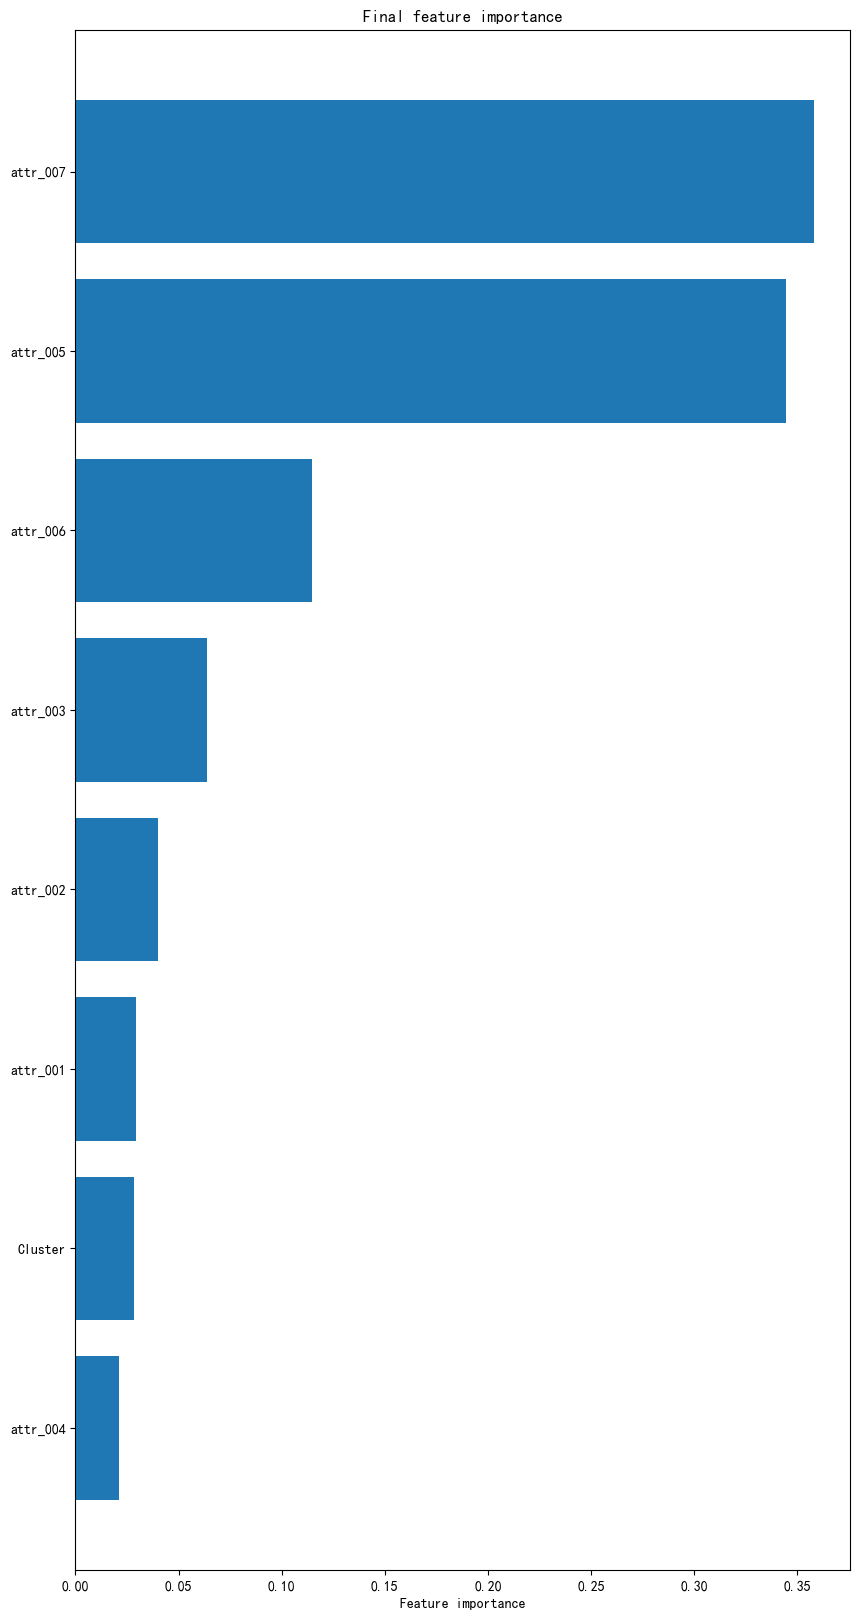

In [46]:
total_importance = np.array([
#     xgb_importance,
    rf_importance,
    et_importance,
    gbdt_importance
])
final_importance = np.mean(total_importance, axis=0)


importance_label = X_train.columns.values

paired_importance = list(zip(final_importance,importance_label))

paired_sorted_importance = sorted(paired_importance)
sorted_importance, sorted_label = zip(*paired_sorted_importance)

plt.figure(figsize=(10,20))
plt.barh(range(len(sorted_importance)),sorted_importance,tick_label=sorted_label)
plt.xlabel('Feature importance')
plt.title('Final feature importance')
plt.savefig('feature_importance.png')
plt.show()
#把该图保存到当前文件夹

In [47]:
import pickle
with open('svr.pkl','wb') as file: pickle.dump(svr_model, file)
with open('gbdt.pkl','wb') as file: pickle.dump(gbdt_model, file)
with open('et.pkl','wb') as file: pickle.dump(et_model, file)
with open('rf.pkl','wb') as file: pickle.dump(rf_model, file)
# with open('xgb.pkl','wb') as file: pickle.dump(xgb_model, file)

# V19.6.13 独立价格服务一键导出

只需要确认 `PRODUCT_CODE`。导出器直接发现Notebook内存里已经训练成功的任意模型，不要求Lasso、Ridge、SVR、GBDT、ExtraTrees、RandomForest、XGBoost全部存在。`X_train` 的英文表头就是价格HTTP服务字段编号，不需要逐字段手写映射。

默认使用当前内存中已经存在的训练模型；如果某个模型训练失败或没有运行相应单元格，会自动跳过。标准化器存在就一并保存，不存在则让模型直接接收原始字段。

权重若能与现有模型对应则自动复用，否则自动等权。模型精度仍由本Notebook的专家训练、验证和选模过程决定，导出器不重新训练模型。

模型文件只能来自可信来源。保存XGBoost模型时目标机仍需对应XGBoost依赖；没有保存XGBoost时不需要安装它。导出完成后双击 `START_PRICE_SERVICE_WIN7.bat` 即可一键部署当前pickle。


In [48]:
from services.price_service.export_native_price_bundle import export_price_service_bundle

# 唯一必须确认的配置：与本批成品数据使用同一个代号。
PRODUCT_CODE = "AIRCRAFT_DOOR_LOCK_BASIC_DEMO"

# 原价格单位若为元填10000；已经是万元填1。
TARGET_DIVISOR_TO_WAN = 1

# 可选：不设置时自动使用当前Notebook内已经训练成功的全部模型。
# PRICE_ENSEMBLE_MODELS = ["ridge", "svr", "gbdt"]
# PRICE_ENSEMBLE_WEIGHTS = {"ridge": 0.5, "svr": 0.2, "gbdt": 0.3}

bundle = export_price_service_bundle(globals())

print("已直接安装到独立价格服务：services/price_service/model/price_native_bundle.pkl")
print("实际保存模型数量：", bundle["export_notes"]["included_model_count"])
print("实际保存模型：", bundle["export_notes"]["included_models"])
print("权重来源：", bundle["export_notes"]["weight_source"])
print("集成配置：", bundle["ensemble"])
print("所需依赖模块：", bundle["required_modules"])


已直接安装到独立价格服务：services/price_service/model/price_native_bundle.pkl
实际保存模型数量： 6
实际保存模型： ['lasso', 'ridge', 'random_forest', 'extra_trees', 'svr', 'gbdt']
权重来源： notebook_weights
集成配置： {'aggregation': 'weighted_mean_price', 'members': [{'name': 'lasso', 'weight': 0.25871790185828375}, {'name': 'ridge', 'weight': 0.2584548840497163}, {'name': 'random_forest', 'weight': 0.08039417200701689}, {'name': 'extra_trees', 'weight': 0.11450410313366705}, {'name': 'svr', 'weight': 0.25118484190832274}, {'name': 'gbdt', 'weight': 0.036744097042993105}]}
所需依赖模块： ['sklearn']


D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
